Original shape read by h5py: (10240, 3, 16, 16)
Shape after transpose fix: (10240, 16, 16, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.007018526..0.007939989].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010329174..0.022169773].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006015279..0.013170065].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.012881834..0.0064568054].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.778264..0.82660115].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.015147315..0.006854096].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).

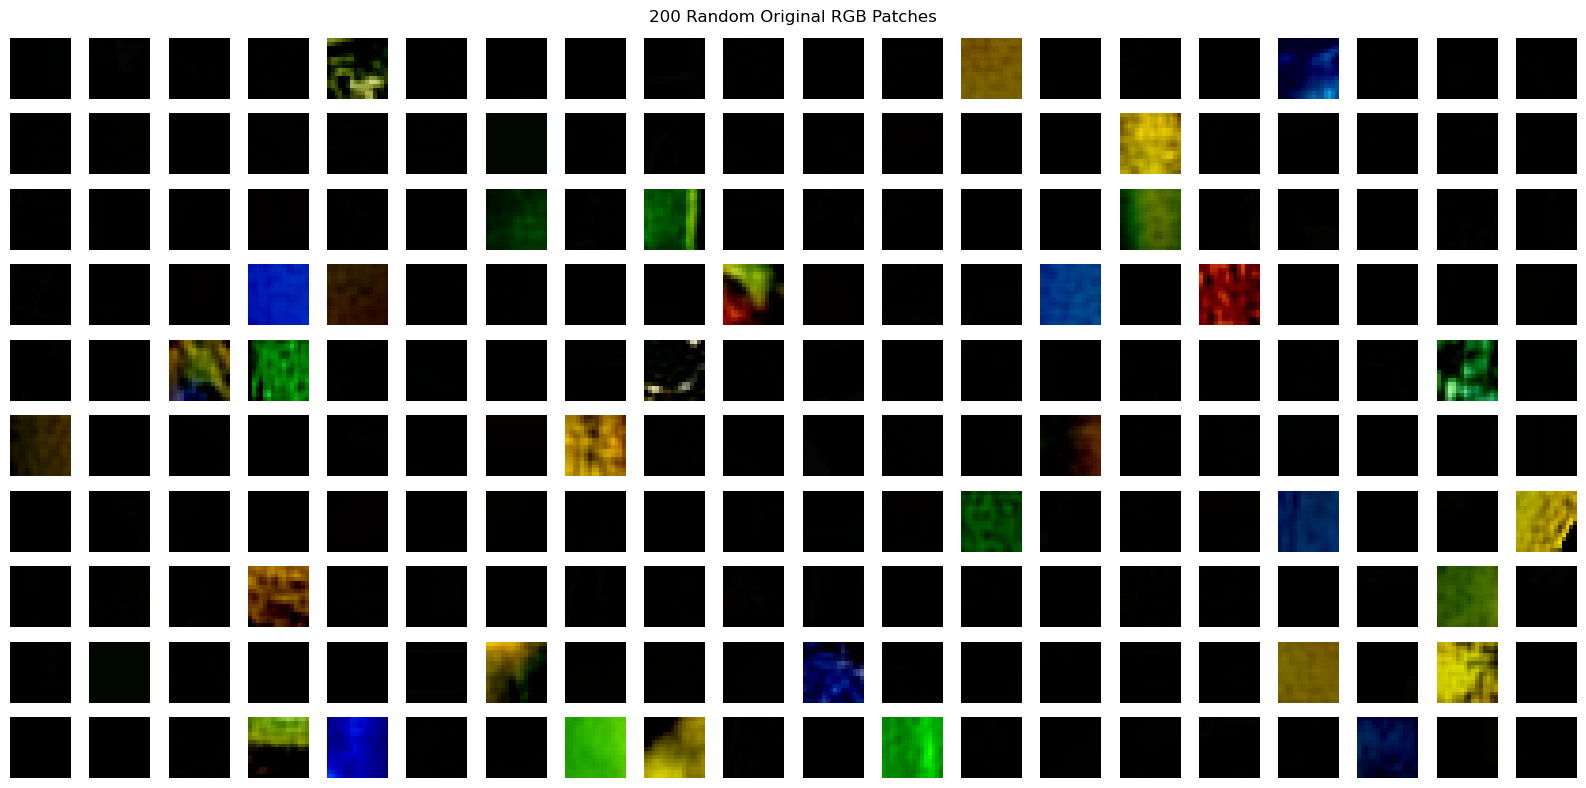

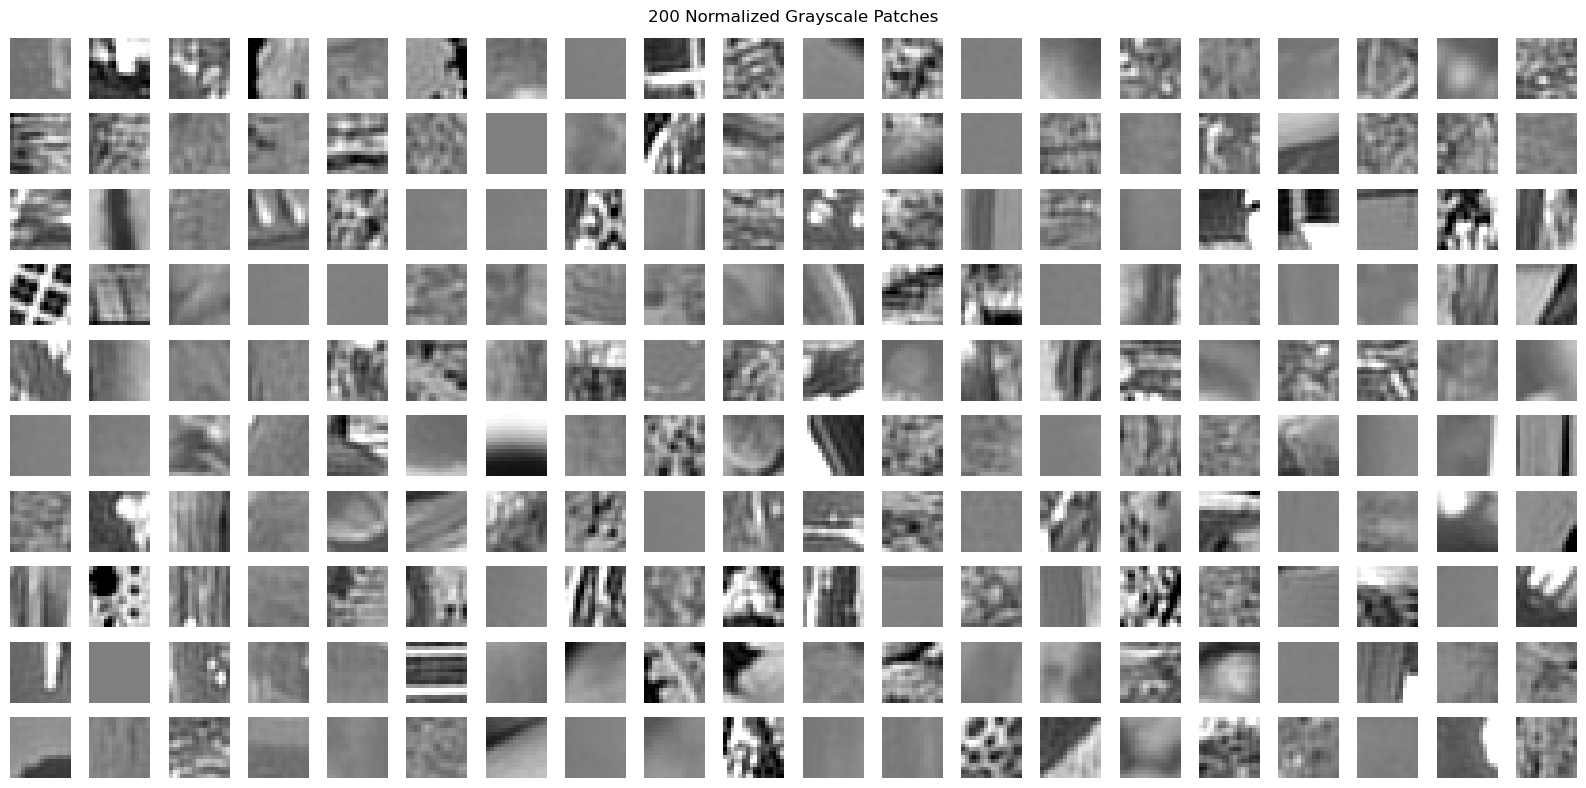

In [11]:
import numpy as np
import h5py  # Use h5py instead of scipy.io
import matplotlib.pyplot as plt

def preprocess_and_visualize(mat_filepath):
    # 1. Load the data using HDF5 reader
    with h5py.File(mat_filepath, 'r') as f:
        # Extract the dataset and convert it to a numpy array
        rgb_patches = np.array(f['data'])
    
    # MATLAB saves HDF5 data transposed compared to Python (column-major vs row-major).
    # If the MATLAB shape was (16, 16, 3, N), h5py will likely read it as (N, 3, 16, 16).
    # We need to transpose it back to (N, 16, 16, 3) for standard image processing.
    
    print(f"Original shape read by h5py: {rgb_patches.shape}")
    
    if rgb_patches.ndim == 4:
        if rgb_patches.shape[1] == 3 and rgb_patches.shape[2] == 16:
            # Shape is (N, 3, 16, 16) -> move axes to (N, 16, 16, 3)
            rgb_patches = np.transpose(rgb_patches, (0, 2, 3, 1))
        elif rgb_patches.shape[0] == 3 and rgb_patches.shape[-1] > 16:
            # Shape is (3, 16, 16, N) -> move axes to (N, 16, 16, 3)
            rgb_patches = np.transpose(rgb_patches, (3, 1, 2, 0))

    print(f"Shape after transpose fix: {rgb_patches.shape}")
    N = rgb_patches.shape[0]

    # 2. Convert to grayscale using the luminosity model
    # Y = 0.2126*R + 0.7152*G + 0.0722*B
    gray_patches = (0.2126 * rgb_patches[:, :, :, 0] + 
                    0.7152 * rgb_patches[:, :, :, 1] + 
                    0.0722 * rgb_patches[:, :, :, 2])
    
    # 3. Remove the mean pixel intensity of each image from itself
    # Calculate mean along the spatial dimensions (axis 1 and 2) and keep dims for broadcasting
    patch_means = np.mean(gray_patches, axis=(1, 2), keepdims=True)
    zero_mean_patches = gray_patches - patch_means
    
    # 4. Clip the data range at +/- 3 standard deviations (measured across ALL pixels)
    global_std = np.std(zero_mean_patches)
    clip_min = -3 * global_std
    clip_max = 3 * global_std
    clipped_patches = np.clip(zero_mean_patches, clip_min, clip_max)
    
    # 5. Map the +/- 3 std data range to [0.1, 0.9]
    # Formula: scaled = 0.1 + (val - min) * (0.9 - 0.1) / (max - min)
    normalized_patches = 0.1 + (clipped_patches - clip_min) * (0.9 - 0.1) / (clip_max - clip_min)
    
# 6. Display 200 random sample patches
    num_samples_to_show = 200
    random_indices = np.random.choice(N, num_samples_to_show, replace=False)
    
    # FIX: Grid is now 10x20 = 200 subplots
    fig, axes = plt.subplots(10, 20, figsize=(16, 8))
    fig.suptitle('200 Random Original RGB Patches')
    for i, ax in enumerate(axes.flat):
        img = rgb_patches[random_indices[i]]
        # Assuming original RGB data is in [0, 255], normalize to [0, 1] for matplotlib if needed
        if img.max() > 1.0:
            img = img / 255.0
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # FIX: Grid is now 10x20 = 200 subplots
    fig, axes = plt.subplots(10, 20, figsize=(16, 8))
    fig.suptitle('200 Normalized Grayscale Patches')
    for i, ax in enumerate(axes.flat):
        ax.imshow(normalized_patches[random_indices[i]], cmap='gray', vmin=0.1, vmax=0.9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    return normalized_patches

# Usage:
normalized_data = preprocess_and_visualize('assign3_data1.mat')

In [13]:
import numpy as np

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def initialize_weights(Lin, Lhid):
    """
    Initializes weights from a uniform distribution [-w0, w0].
    """
    # w0 for W1 (Lpre = Lin, Lpost = Lhid)
    w0_1 = np.sqrt(6.0 / (Lin + Lhid))
    W1 = np.random.uniform(-w0_1, w0_1, (Lhid, Lin))
    b1 = np.random.uniform(-w0_1, w0_1, (Lhid, 1))

    # w0 for W2 (Lpre = Lhid, Lpost = Lout = Lin)
    w0_2 = np.sqrt(6.0 / (Lhid + Lin))
    W2 = np.random.uniform(-w0_2, w0_2, (Lin, Lhid))
    b2 = np.random.uniform(-w0_2, w0_2, (Lin, 1))

    # Flatten and concatenate into a single vector We
    We = np.concatenate((W1.flatten(), W2.flatten(), b1.flatten(), b2.flatten()))
    return We

def aeCost(We, data, params):
    """
    Calculates the cost J and its partial derivatives Jgrad.
    data is expected to be of size (Lin, N).
    """
    Lin = params['Lin']
    Lhid = params['Lhid']
    lam = params['lambda']
    beta = params['beta']
    rho = params['rho']
    
    N = data.shape[1]

    # --- 1. Unpack the We vector ---
    idx = 0
    W1 = We[idx : idx + Lhid*Lin].reshape(Lhid, Lin)
    idx += Lhid*Lin
    W2 = We[idx : idx + Lin*Lhid].reshape(Lin, Lhid)
    idx += Lin*Lhid
    b1 = We[idx : idx + Lhid].reshape(Lhid, 1)
    idx += Lhid
    b2 = We[idx : idx + Lin].reshape(Lin, 1)

    # --- 2. Forward Pass ---
    z1 = np.dot(W1, data) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(W2, a1) + b2
    a2 = sigmoid(z2)

    # --- 3. Compute Cost (J) ---
    # Average squared-error
    mse_cost = (1.0 / (2 * N)) * np.sum((data - a2) ** 2)
    
    # Tykhonov regularization (weight decay)
    reg_cost = (lam / 2.0) * (np.sum(W1 ** 2) + np.sum(W2 ** 2))
    
    # Sparsity penalty (KL Divergence)
    rho_hat = np.mean(a1, axis=1, keepdims=True)
    # Clip rho_hat to avoid log(0) or division by zero errors during early training
    rho_hat = np.clip(rho_hat, 1e-10, 1 - 1e-10) 
    
    kl_div = rho * np.log(rho / rho_hat) + (1 - rho) * np.log((1 - rho) / (1 - rho_hat))
    sparse_cost = beta * np.sum(kl_div)
    
    J = mse_cost + reg_cost + sparse_cost

    # --- 4. Backward Pass (Compute Gradients) ---
    # Output layer error
    delta2 = -(data - a2) * a2 * (1 - a2)
    
    # Hidden layer error with sparsity penalty derivative incorporated
    sparsity_penalty = beta * (-(rho / rho_hat) + ((1 - rho) / (1 - rho_hat)))
    delta1 = (np.dot(W2.T, delta2) + sparsity_penalty) * a1 * (1 - a1)

    # Gradients w.r.t weights and biases
    W2_grad = (1.0 / N) * np.dot(delta2, a1.T) + lam * W2
    b2_grad = (1.0 / N) * np.sum(delta2, axis=1, keepdims=True)
    
    W1_grad = (1.0 / N) * np.dot(delta1, data.T) + lam * W1
    b1_grad = (1.0 / N) * np.sum(delta1, axis=1, keepdims=True)

    # Pack gradients back into a single vector
    Jgrad = np.concatenate((W1_grad.flatten(), W2_grad.flatten(), 
                            b1_grad.flatten(), b2_grad.flatten()))

    return J, Jgrad

Starting training...
Epoch 0    | Cost: 30.4088
Epoch 100  | Cost: 1.9934
Epoch 200  | Cost: 1.8833
Epoch 300  | Cost: 1.6271
Epoch 400  | Cost: 1.4138
Epoch 500  | Cost: 1.3387
Epoch 600  | Cost: 1.3135
Epoch 700  | Cost: 1.2970
Epoch 800  | Cost: 1.2796
Epoch 900  | Cost: 1.2587
Epoch 1000 | Cost: 1.2342
Epoch 1100 | Cost: 1.2070
Epoch 1200 | Cost: 1.1791
Epoch 1300 | Cost: 1.1526
Epoch 1400 | Cost: 1.1290
Final Cost: 1.1090


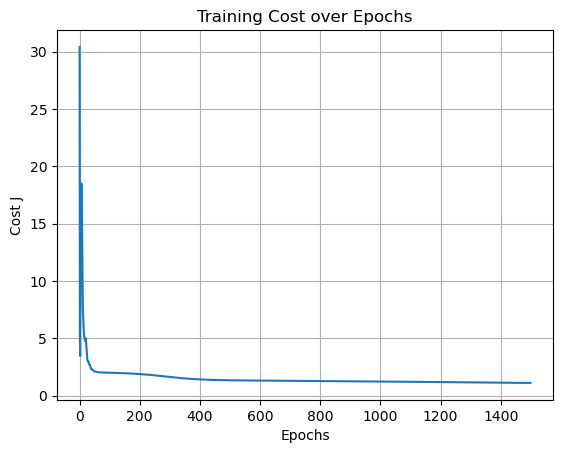

In [21]:
def gradient_descent(We, data, params, learning_rate=0.05, epochs=1500, momentum=0.9):
    """
    Gradient Descent solver with Momentum to stabilize learning and prevent explosion.
    """
    cost_history = []
    velocity = np.zeros_like(We)
    
    for epoch in range(epochs):
        J, Jgrad = aeCost(We, data, params)
        
        # Momentum update rule
        velocity = momentum * velocity + learning_rate * Jgrad
        We = We - velocity
        
        cost_history.append(J)
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch:<4} | Cost: {J:.4f}")
            
    return We, cost_history

# --- Execution Setup ---

# 1. Format the data 
# Using the correct normalized_data variable
N = normalized_data.shape[0]
Lin = 16 * 16

# Flatten each 16x16 patch into a 256 vector, then transpose so shape is (Lin, N)
data_matrix = normalized_data.reshape(N, Lin).T 

# 2. Define Parameters
params = {
    'Lin': Lin,
    'Lhid': 64,          # As specified in the assignment
    'lambda': 5e-4,      # As specified in the assignment
    'beta': 1.0,         # Lowered from 3.0 to 1.0 for a more stable start
    'rho': 0.1           # Sparsity target
}

# 3. Initialize Weights
We_initial = initialize_weights(params['Lin'], params['Lhid'])

# 4. Train the Network
print("Starting training...")
We_trained, costs = gradient_descent(
    We=We_initial, 
    data=data_matrix, 
    params=params, 
    learning_rate=0.05,   # Drastically reduced to prevent saturation
    momentum=0.9,         # Added momentum
    epochs=1500          
)
print(f"Final Cost: {costs[-1]:.4f}")

# Optional: Plot the learning curve to verify smooth descent
plt.plot(costs)
plt.title('Training Cost over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Cost J')
plt.grid(True)
plt.show()